# fitness-rl — end-to-end walkthrough

This notebook reproduces the full pipeline in 6 cells: **data → world model → REINFORCE → A2C → PPO → 28-day recommendation**. Every cell is self-contained against the SDK and reads `configs/setup.json` for hyperparameters.

> Tip: open from the repo root with `jupyter notebook notebooks/fitness_rl_walkthrough.ipynb`. The SDK auto-resolves paths from the project root.

## 1 — Load the data pipeline

`DataService` walks the Kaggle CSVs → trajectory → 16-d state vectors. Reproducible: seed is fixed in `configs/setup.json`.

In [1]:
import json, sys
from pathlib import Path

# Allow running the notebook from anywhere by walking up to the assignment root.
ROOT = next(p for p in Path.cwd().resolve().parents if (p / 'configs' / 'setup.json').exists()) \
       if not (Path.cwd() / 'configs' / 'setup.json').exists() else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from fitness_rl.sdk.sdk import FitnessRL
from fitness_rl.sdk.evaluator import FitnessRLEvaluator

sdk = FitnessRL(config_path=ROOT / 'configs' / 'setup.json')
data = sdk.prepare_data()
print(f'Chosen program: {data.chosen_title}')
print(f'Days: {len(data.trajectory)}  state dim: {data.states.shape[1]}')
print(f'Action distribution: ' + ', '.join(
    f"{a.name}={int((data.actions == int(a)).sum())}" for a in __import__('fitness_rl.shared.types', fromlist=['Action']).Action))

2026-06-03 10:21:06,755 INFO    [fitness_rl.data.kaggle_loader] loading /home/corsight/src/RL_Course/assignment3/data/raw/program_summary.csv


2026-06-03 10:21:06,773 INFO    [fitness_rl.data.kaggle_loader] loading /home/corsight/src/RL_Course/assignment3/data/raw/programs_detailed_boostcamp_kaggle.csv (large file, may take a moment)


2026-06-03 10:21:09,223 INFO    [fitness_rl.data.kaggle_loader] loaded: 2598 programs, 605033 detailed rows


2026-06-03 10:21:09,846 INFO    [fitness_rl.data.preprocessor] preprocessor: dropped 7721 rows with NaN/invalid


2026-06-03 10:21:09,996 INFO    [fitness_rl.data.program_selector] selected program: '(MASS MONSTER) High Intensity 4 Day Upper Lower Program' (week=12, time=90)


2026-06-03 10:21:10,117 INFO    [fitness_rl.data.trajectory_builder] trajectory built: 84 days (84 training + 0 rest)


2026-06-03 10:21:10,118 INFO    [fitness_rl.services.data_service] pipeline output: chosen='(MASS MONSTER) High Intensity 4 Day Upper Lower Program', 84 days, state_dim=16


Chosen program: (MASS MONSTER) High Intensity 4 Day Upper Lower Program
Days: 84  state dim: 16
Action distribution: PUSH=23, PULL=3, LEGS=22, CARDIO=0, REST=36


## 2 — Train the LSTM world model (Part C)

Supervised on rolling 7-day windows. Early stopping by validation loss.

In [2]:
wm_result = sdk.train_world_model()
print(f'Best val MSE: {wm_result.best_val_loss:.6f} at epoch {wm_result.best_epoch}')
print(f'Early stopped: {wm_result.stopped_early}')

# Validate against persistence + linear baselines (audit #1)
ev = FitnessRLEvaluator(sdk)
wm_report = ev.evaluate_world_model(horizons=(1, 7))
print(f'Persistence 1-step MSE: {wm_report.persistence_one_step_mse:.4f}')
print(f'LSTM 1-step MSE:        {wm_report.lstm_one_step_mse:.4f}')
print(f'LSTM 7-step rollout MSE: {wm_report.lstm_rollout_mse[7]:.4f} (error compounds)')

2026-06-03 10:21:10,513 INFO    [fitness_rl.sdk.sdk] world model saved to /home/corsight/src/RL_Course/assignment3/saved_models/world_model.pt


Best val MSE: 0.007832 at epoch 97
Early stopped: False
Persistence 1-step MSE: 0.1754
LSTM 1-step MSE:        0.0098
LSTM 7-step rollout MSE: 0.0091 (error compounds)


## 3 — Train REINFORCE (Part D)

Episodic policy gradient with mean baseline + reward-to-go.

In [3]:
reinforce_hist = sdk.train_reinforce(episodes=60)
print(f'REINFORCE — episodes: {len(reinforce_hist)}, final reward: {reinforce_hist[-1].total_reward:.3f}')

REINFORCE — episodes: 60, final reward: 5.213


## 4 — Train A2C (Part E)

Per-step TD advantage with shared trunk + actor/critic heads.

In [4]:
a2c_hist = sdk.train_a2c(episodes=60)
print(f'A2C — episodes: {len(a2c_hist)}, final reward: {a2c_hist[-1].total_reward:.3f}')

A2C — episodes: 60, final reward: 5.162


## 5 — Train PPO (Layer 15 — beyond-spec)

Clipped surrogate objective + multi-epoch updates per batch.

PPO — episodes: 60, final reward: 0.093


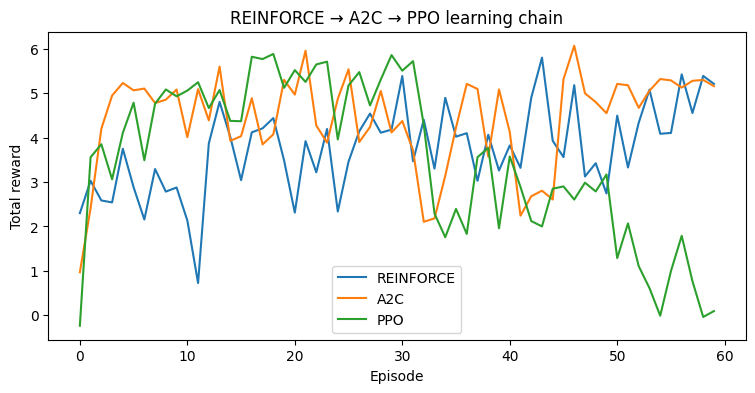

In [5]:
ppo_hist = sdk.train_ppo(episodes=60)
print(f'PPO — episodes: {len(ppo_hist)}, final reward: {ppo_hist[-1].total_reward:.3f}')

# Side-by-side curve in one plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([m.total_reward for m in reinforce_hist], label='REINFORCE')
ax.plot([m.total_reward for m in a2c_hist], label='A2C')
ax.plot([m.total_reward for m in ppo_hist], label='PPO')
ax.set(xlabel='Episode', ylabel='Total reward',
       title='REINFORCE → A2C → PPO learning chain')
ax.legend(); plt.show()

## 6 — Recommend the next 7 days

The user-facing product: feed your recent workout history → get a 7-day plan with per-day reward breakdown.

In [6]:
from fitness_rl.environment.reward import RewardFunction
from fitness_rl.services.recommender import WorkoutRecommender

cfg = sdk.config
reward_fn = RewardFunction(
    gain_weight=float(cfg.get('env.reward_gain_weight')),
    overload_lambda=float(cfg.get('env.reward_overload_lambda')),
    imbalance_lambda=float(cfg.get('env.reward_imbalance_lambda')),
)
plan = WorkoutRecommender().recommend(
    net=sdk._require_net('a2c'),
    env=sdk.make_env(),
    reward_fn=reward_fn,
    n_days=7,
    recent_actions=WorkoutRecommender.parse_history('PUSH,PUSH,REST'),
)
print(plan.as_table())

Day  Workout   Gain  Overload  Imbalance  Reward
------------------------------------------------
  1     PUSH  0.320     0.064      0.110   0.146
  2   CARDIO  0.046     0.037      0.111  -0.101
  3     PUSH  0.243     0.041      0.171   0.031
  4     PUSH  0.055     0.033      0.165  -0.143
  5     PUSH  0.270     0.037      0.125   0.108
  6     PUSH  0.105     0.035      0.137  -0.066
  7     PUSH  0.237     0.036      0.125   0.076

Expected total reward: 0.050


## What's next?

- Run `scripts/run_layer15_full.py` for the full 300-episode × 3-seed comparison.
- See `results/layer15/full_budget_multiseed.json` for the headline numbers and `assets/plots/three_algo_*.png` for the figures.
- See `README.md` § 9 for the full audit-driven empirical analysis.